# Lab 2 — Digital Image Fundamentals
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers the lab manual:
1. **Sampling and Quantization**
2. **Arithmetic Operations** (add, subtract, add constant)
3. **Set / Logical Operations** (union, intersection, difference, symmetric difference)
4. **Practical Tasks**

> **Note on images:** The lab references `lena_gray_256.tif`, `cameraman.tif`, `A.png`, `B.png`. Since those files aren't bundled with the notebook, this notebook uses built-in `skimage` images so every cell runs out of the box. To use your own image, just replace the loading line.

## Setup

In [4]:
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

---
## Section 1 — Image Sampling and Quantization

- **Sampling** = how many pixels we keep (spatial resolution).
- **Quantization** = how many gray levels we keep (intensity resolution).

In [10]:
def sample_image(image, factor):
    """Downsamples the image by the given factor."""
    # changing the shape of the image
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """Reduces the number of grayscale levels in the image."""
    # darkening for image
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    # 0 to256 are the gray color degrees
    # lets say we want the color to be in levels=9 only then equation will be 100(/265//9) ....etc
    # result will be 85.2. color degree is from 0 to 256, 0 being the darkest. result 85.2 close to zero so image colors are more intensed (darking) now.
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray')
    plt.title('Original Image'), plt.axis('off')
    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image'), plt.axis('off')
    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image'), plt.axis('off')
    plt.show()

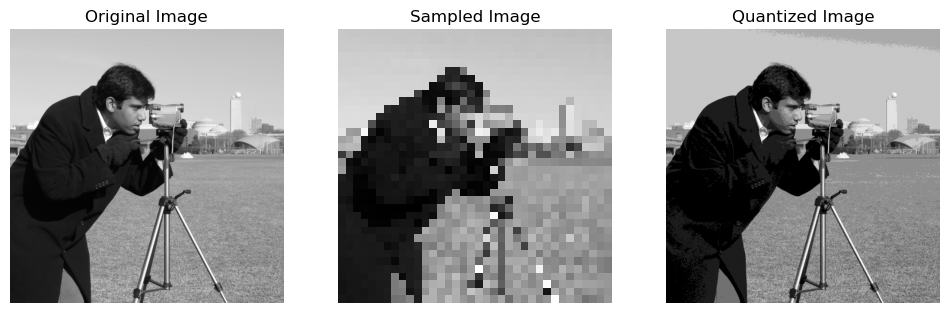

In [15]:
original_image = data.camera()

sampling_factor = 14
quantization_levels = 9
# level 9 make image a bit darkend, levels 1 make pic completly black. the lower the levels the darker.

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

---
## Section 2 — Arithmetic Operations

Add two images by converting them to numpy arrays and adding element-wise.

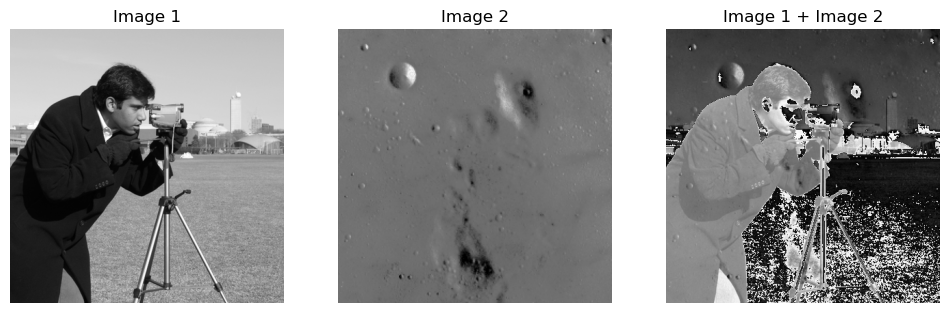

In [7]:
img1 = Image.fromarray(data.camera())
img2 = Image.fromarray(data.moon())
# must resize before opertions, so that the 2 images are the same size
new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)
# Resampling.LANCZOS is better then nearest, bc it chooses the nearest while making other calculations as well.
im1arr = np.asarray(img1) # transfrom them back to array
im2arr = np.asarray(img2)

addition = im1arr + im2arr
result_image = Image.fromarray(addition) # 

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.show()

---
## Section 3 — Set / Logical Operations

Pixel-wise bitwise operations on two images. Lab demo: **union (OR)**.

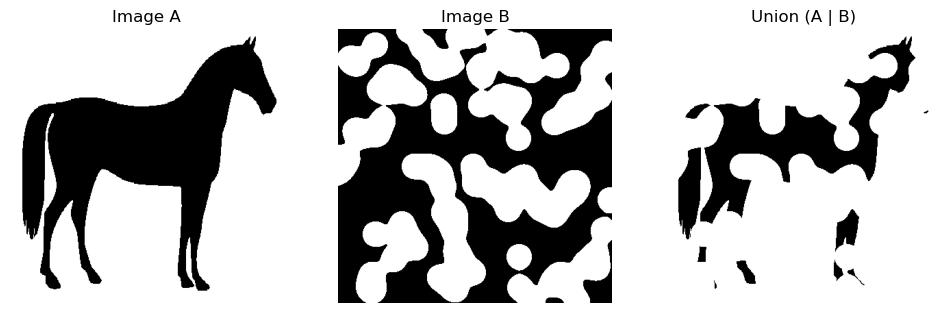

In [14]:
img3 = Image.fromarray(data.horse()) # download the image
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3) # transfer the image into an array to do the math operations 
im4arr = np.asarray(img4)

union = im4arr | im3arr 
# transfer back to image to display it
result_image_2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

---
# Practical Tasks

## Task 1 — Change sampling and quantization parameters and observe the effects

Try multiple values of the sampling factor and the number of quantization levels to see how each affects the image.

### 1a) Effect of sampling factor (spatial resolution)

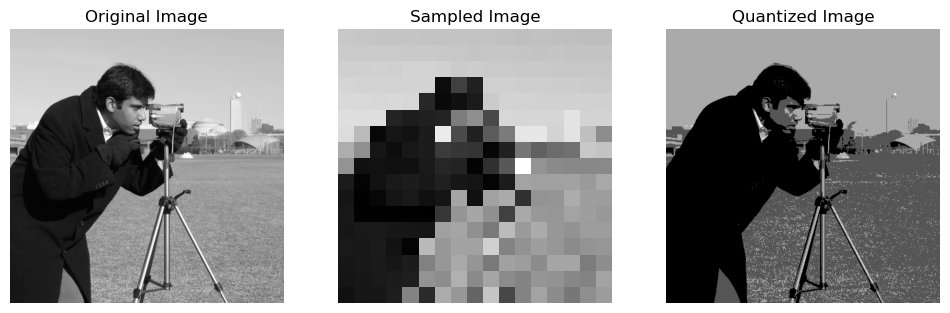

In [24]:
original_image = data.camera()

sampling_factor = 30
quantization_levels = 3
# sampling factor=1 give the og image,
# sampling factor=30 made the quality decrease, and image lost more detailes
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

### 1b) Effect of quantization levels (intensity resolution)

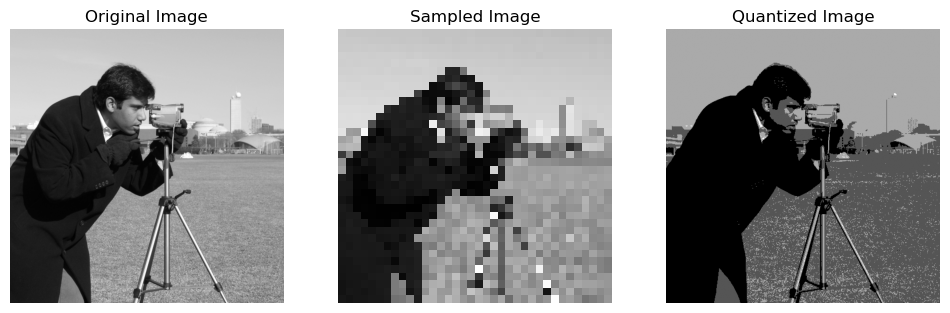

In [29]:
original_image = data.camera()

sampling_factor = 14
quantization_levels = 3
# level 9 make image a bit darkend, levels 1 make pic completly black. the lower the levels the darker.

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

---
## Task 2 — Image Arithmetic and Set Operations

Required operations:
1. Subtract two images and display the result
2. Add one image with a constant value 175
3. Set difference on two grayscale images
4. Symmetric difference on two grayscale images
5. Intersection on two grayscale images

### 2a) Subtract two images

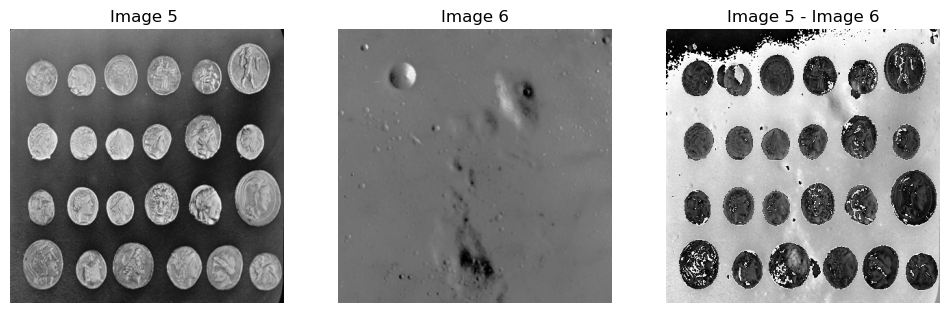

In [35]:
img5 = Image.fromarray(data.coins())
img6 = Image.fromarray(data.moon())

new_size = (400, 400)
img5 = img5.resize(new_size, Image.Resampling.LANCZOS)
img6 = img6.resize(new_size, Image.Resampling.LANCZOS)

im5arr = np.asarray(img5) # transfrom them back to array
im6arr = np.asarray(img6)

sub = im5arr - im6arr
result_image = Image.fromarray(sub) 

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img5, cmap='gray'), plt.title('Image 5 '), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img6, cmap='gray'), plt.title('Image 6'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 5 - Image 6'), plt.axis('off')
plt.show()

### 2b) Add image with constant value 175

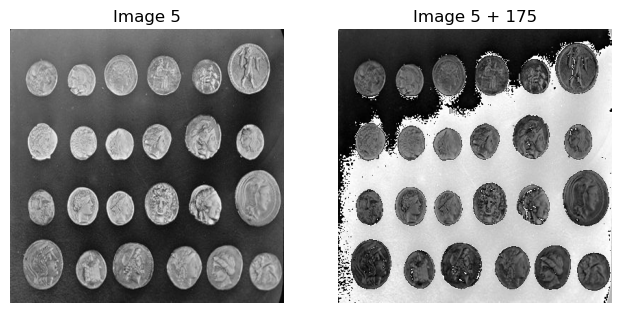

In [36]:
img5 = Image.fromarray(data.coins())

new_size = (400, 400)
img5 = img5.resize(new_size, Image.Resampling.LANCZOS)

im5arr = np.asarray(img5) # transfrom back to array

add = im5arr + 175
result_image = Image.fromarray(add) 

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img5, cmap='gray'), plt.title('Image 5'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(result_image, cmap='gray'), plt.title('Image 5 + 175'), plt.axis('off')
plt.show()

result: picture came light in some areas

### 2c-2e) Set operations on grayscale images

| Operation | Bitwise formula | Meaning |
|---|---|---|
| **Intersection** | `A & B` | bits set in both |
| **Set difference** | `A & ~B` (A − B) | bits in A but not in B |
| **Symmetric difference** | `A ^ B` | bits in A or B but not both |
| **Union** (extra) | `A \| B` | bits in either |

Set difference on two grayscale images

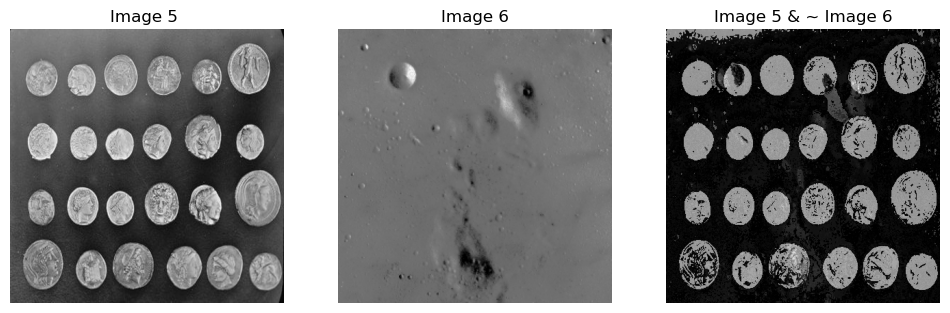

In [40]:
img5 = Image.fromarray(data.coins())
img6 = Image.fromarray(data.moon())

new_size = (400, 400)
img5 = img5.resize(new_size, Image.Resampling.LANCZOS)
img6 = img6.resize(new_size, Image.Resampling.LANCZOS)

im5arr = np.asarray(img5) # transfrom them back to array
im6arr = np.asarray(img6)

set_diff = im5arr & ( ~ im6arr)
result_image = Image.fromarray(set_diff) 

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img5, cmap='gray'), plt.title('Image 5 '), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img6, cmap='gray'), plt.title('Image 6'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 5 & ~ Image 6'), plt.axis('off')
plt.show()

Symmetric difference on two grayscale images

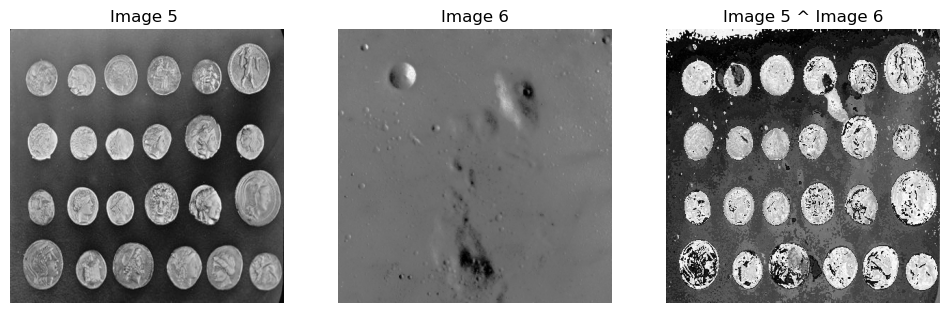

In [41]:
img5 = Image.fromarray(data.coins())
img6 = Image.fromarray(data.moon())

new_size = (400, 400)
img5 = img5.resize(new_size, Image.Resampling.LANCZOS)
img6 = img6.resize(new_size, Image.Resampling.LANCZOS)

im5arr = np.asarray(img5) # transfrom them back to array
im6arr = np.asarray(img6)

sym_diff = im5arr ^ im6arr
result_image = Image.fromarray(sym_diff) 

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img5, cmap='gray'), plt.title('Image 5 '), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img6, cmap='gray'), plt.title('Image 6'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 5 ^ Image 6'), plt.axis('off')
plt.show()

Intersection on two grayscale images

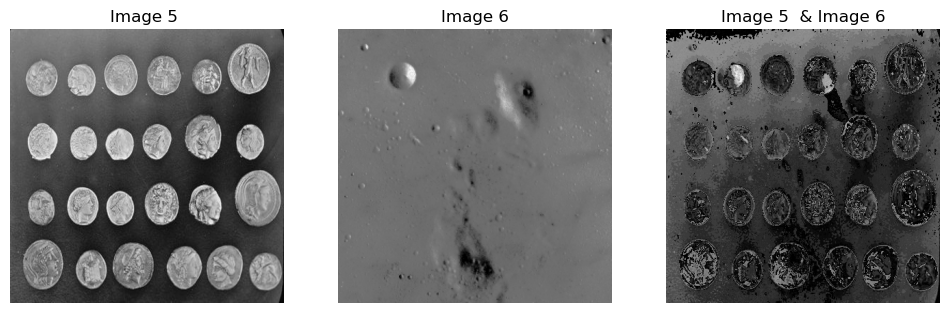

In [42]:
img5 = Image.fromarray(data.coins())
img6 = Image.fromarray(data.moon())

new_size = (400, 400)
img5 = img5.resize(new_size, Image.Resampling.LANCZOS)
img6 = img6.resize(new_size, Image.Resampling.LANCZOS)

im5arr = np.asarray(img5) # transfrom them back to array
im6arr = np.asarray(img6)

Intersection = im5arr  & im6arr
result_image = Image.fromarray(Intersection) 

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img5, cmap='gray'), plt.title('Image 5 '), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img6, cmap='gray'), plt.title('Image 6'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 5  & Image 6'), plt.axis('off')
plt.show()

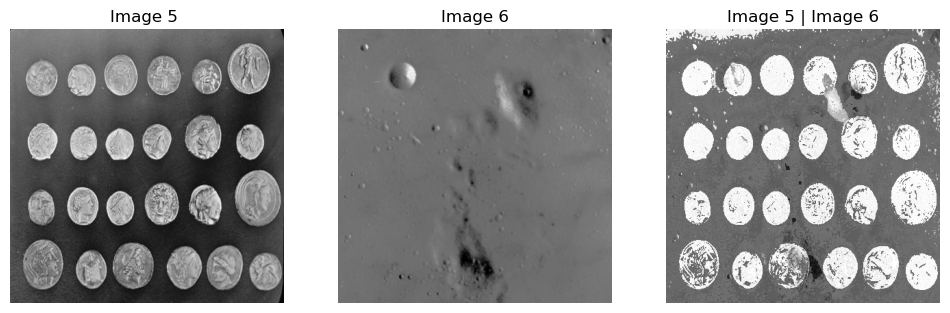

In [43]:
# union 
img5 = Image.fromarray(data.coins())
img6 = Image.fromarray(data.moon())

new_size = (400, 400)
img5 = img5.resize(new_size, Image.Resampling.LANCZOS)
img6 = img6.resize(new_size, Image.Resampling.LANCZOS)

im5arr = np.asarray(img5) # transfrom them back to array
im6arr = np.asarray(img6)

union = im5arr | im6arr
result_image = Image.fromarray(union) 

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img5, cmap='gray'), plt.title('Image 5 '), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img6, cmap='gray'), plt.title('Image 6'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 5 | Image 6'), plt.axis('off')
plt.show()